# Visualization of AR dataset

shape: (256, 512) dtype: float64 min/max: 0.27739998 6.8270916630668825


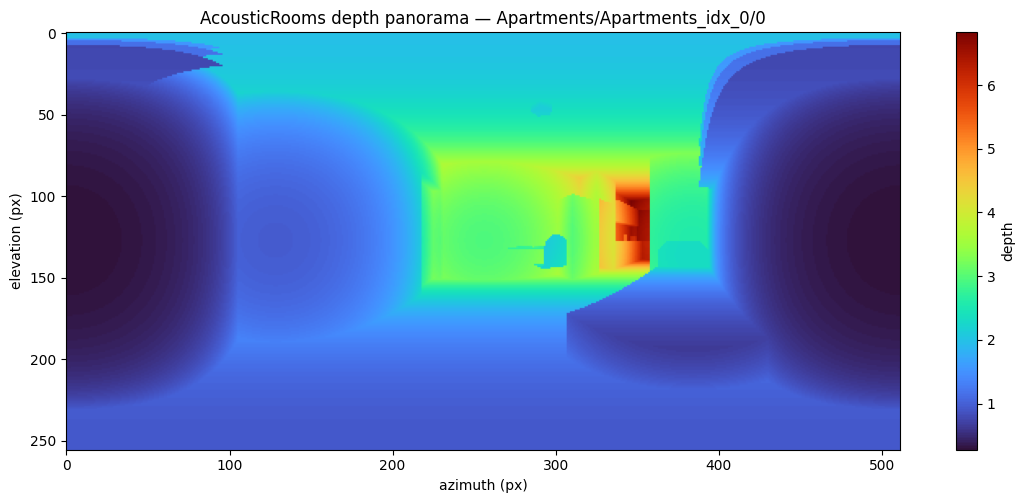

In [8]:
import numpy as np
import matplotlib.pyplot as plt

depth_path = '/home/yixunhu/codespace/FLAC/AcousticRooms/depth_map/Apartments/Apartments_idx_0/0.npy'
depth = np.load(depth_path)
print('shape:', depth.shape, 'dtype:', depth.dtype, 'min/max:', depth.min(), depth.max())

plt.figure(figsize=(12, 5))
im = plt.imshow(depth, cmap='turbo')
plt.colorbar(im, label='depth')
plt.title('AcousticRooms depth panorama — Apartments/Apartments_idx_0/0')
plt.xlabel('azimuth (px)')
plt.ylabel('elevation (px)')
plt.tight_layout()
plt.show()

In [12]:
import os

metadata_dir = '/home/yixunhu/codespace/FLAC/AcousticRooms/metadata/Apartments/Apartments_idx_0/'
entries = os.listdir(metadata_dir)
files = [e for e in entries if os.path.isfile(os.path.join(metadata_dir, e))]
print(f'Total entries: {len(entries)}')

Total entries: 1600


In [13]:
import os
import re
from collections import defaultdict

metadata_dir = '/home/yixunhu/codespace/FLAC/AcousticRooms/metadata/Apartments/Apartments_idx_0/'

# Filename pattern: S<src_id>_R<rec_id>.json  (digit width is variable, e.g. S001 or S0042)
pat = re.compile(r'^S(\d+)_R(\d+)\.json$')

pairs = []
src_to_recs = defaultdict(set)
rec_to_srcs = defaultdict(set)
malformed = []

for fname in sorted(os.listdir(metadata_dir)):
    m = pat.match(fname)
    if not m:
        malformed.append(fname)
        continue
    src, rec = int(m.group(1)), int(m.group(2))
    pairs.append((src, rec))
    src_to_recs[src].add(rec)
    rec_to_srcs[rec].add(src)

unique_srcs = sorted(src_to_recs.keys())
unique_recs = sorted(rec_to_srcs.keys())

print(f'Total (src, rec) pairs : {len(pairs)}')
print(f'Unique source ids      : {len(unique_srcs)}  (range {min(unique_srcs)}–{max(unique_srcs)})')
print(f'Unique receiver ids    : {len(unique_recs)}  (range {min(unique_recs)}–{max(unique_recs)})')
print(f'Expected if full grid  : {len(unique_srcs) * len(unique_recs)}')
print(f'Malformed filenames    : {len(malformed)}')

# Sanity check: is it a complete src × rec grid? If so, every src has the same set of recs.
recs_per_src = {len(v) for v in src_to_recs.values()}
print(f'\nrecs-per-src cardinalities: {recs_per_src}  (singleton => uniform grid)')
srcs_per_rec = {len(v) for v in rec_to_srcs.values()}
print(f'srcs-per-rec cardinalities: {srcs_per_rec}')

# Quick peek at the first few pairs
print('\nFirst 10 pairs (src, rec):', pairs[:10])
print('Last  10 pairs (src, rec):', pairs[-10:])

Total (src, rec) pairs : 1600
Unique source ids      : 32  (range 0–39)
Unique receiver ids    : 50  (range 0–49)
Expected if full grid  : 1600
Malformed filenames    : 0

recs-per-src cardinalities: {50}  (singleton => uniform grid)
srcs-per-rec cardinalities: {32}

First 10 pairs (src, rec): [(0, 0), (0, 1), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17)]
Last  10 pairs (src, rec): [(8, 45), (8, 46), (8, 47), (8, 48), (8, 49), (8, 5), (8, 6), (8, 7), (8, 8), (8, 9)]
